# CNV benchmark

In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import seaborn.objects as so

custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [205]:
base_path = Path("../analysis/cnv_benchmark")

samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
human_samples = samples.query("Genome == 'Human'")
human_samples

,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
1,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell
2,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell
3,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell
4,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell
5,P33410_1006,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
7,P33410_1008,Q_A3_cell_07,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#07),Single cell
8,P33410_1009,Q_B3_cell_08,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#08),Single cell
9,P33410_1010,Q_C3_cell_09,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#09),Single cell
10,P33410_1011,Q_D3_cell_10,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#10),Single cell


## Agreement

In [206]:
list((base_path / "agreement").rglob("*.tsv"))

[PosixPath('../analysis/cnv_benchmark/agreement/penncnv/array/PacBio_HiFi/none.gl.tsv'),
 PosixPath('../analysis/cnv_benchmark/agreement/penncnv/array/PacBio_HiFi/none.cn.tsv'),
 PosixPath('../analysis/cnv_benchmark/agreement/penncnv/array/OGM/none.gl.tsv'),
 PosixPath('../analysis/cnv_benchmark/agreement/penncnv/array/OGM/none.cn.tsv'),
 PosixPath('../analysis/cnv_benchmark/agreement/copykit/full/PacBio_HiFi/220kb.gl.tsv'),
 PosixPath('../analysis/cnv_benchmark/agreement/copykit/full/PacBio_HiFi/1Mb.cn.tsv'),
 PosixPath('../analysis/cnv_benchmark/agreement/copykit/full/PacBio_HiFi/110kb.gl.tsv'),
 PosixPath('../analysis/cnv_benchmark/agreement/copykit/full/PacBio_HiFi/500kb.cn.tsv'),
 PosixPath('../analysis/cnv_benchmark/agreement/copykit/full/PacBio_HiFi/220kb.cn.tsv'),
 PosixPath('../analysis/cnv_benchmark/agreement/copykit/full/PacBio_HiFi/1Mb.gl.tsv'),
 PosixPath('../analysis/cnv_benchmark/agreement/copykit/full/PacBio_HiFi/110kb.cn.tsv'),
 PosixPath('../analysis/cnv_benchmark/agr

In [207]:
data = []

for tsv in (base_path / "agreement").rglob("*.tsv"):
    binsize, benchtype = tsv.stem.split(".")
    truthset = tsv.parent.stem
    readdepth = tsv.parent.parent.stem
    caller = tsv.parent.parent.parent.stem

    df = pd.read_csv(tsv, sep="\t", names=["NGI ID", "Agreement"])
    df["Truthset"] = truthset
    df["Caller"] = caller
    df["Binsize"] = binsize
    df["Readdepth"] = readdepth
    df["Benchtype"] = benchtype

    if "penncnv" == caller:
        # Replace names
        df["NGI ID"] = df["NGI ID"].replace(samples.set_index("User ID")["NGI ID"].to_dict())
    data.append(df)

data = pd.concat(data).reset_index(drop=True)
data = data.merge(samples, on="NGI ID")
data = data.query("Genome == 'Human'")
data["Caller_Binsize"] = data[["Caller","Binsize"]].apply(lambda x: f"{x[0]}\n({x[1]})", axis=1)
data["Kit_Readdepth"] = data[["Kit","Readdepth"]].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)
data

/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_75200/2075986270.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data["Caller_Binsize"] = data[["Caller","Binsize"]].apply(lambda x: f"{x[0]}\n({x[1]})", axis=1)
/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_75200/2075986270.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data["Kit_Readdepth"] = data[["Kit","Readdepth"]].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)


,NGI ID,Agreement,Truthset,Caller,Binsize,Readdepth,Benchtype,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Caller_Binsize,Kit_Readdepth
0,P33410_1024,0.930160,PacBio_HiFi,penncnv,none,array,gl,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk,penncnv\n(none),BioSkryb (array)
1,P33410_1013,0.917860,PacBio_HiFi,penncnv,none,array,gl,B_A3_cell_01,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#01),Single cell,penncnv\n(none),BioSkryb (array)
2,P33410_1015,0.918507,PacBio_HiFi,penncnv,none,array,gl,B_B1_cell_03,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#03),Single cell,penncnv\n(none),BioSkryb (array)
3,P33410_1021,0.906133,PacBio_HiFi,penncnv,none,array,gl,B_C3_cell_09,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#09),Single cell,penncnv\n(none),BioSkryb (array)
4,P33410_1017,0.912762,PacBio_HiFi,penncnv,none,array,gl,B_B3_cell_05,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#05),Single cell,penncnv\n(none),BioSkryb (array)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,P33410_1019,0.493479,OGM,ginkgo,1Mb,2M,gl,B_C1_cell_07,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#07),Single cell,ginkgo\n(1Mb),BioSkryb (2M)
1148,P33410_1020,0.548465,OGM,ginkgo,1Mb,2M,gl,B_C2_cell_08,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#08),Single cell,ginkgo\n(1Mb),BioSkryb (2M)
1149,P33410_1021,0.864922,OGM,ginkgo,1Mb,2M,gl,B_C3_cell_09,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#09),Single cell,ginkgo\n(1Mb),BioSkryb (2M)
1150,P33410_1022,0.857328,OGM,ginkgo,1Mb,2M,gl,B_C4_cell_10,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#10),Single cell,ginkgo\n(1Mb),BioSkryb (2M)


In [208]:
def plot_agreement(d, ylabel, filename=None):
    hue_order = sorted(d["Kit_Readdepth"].unique())
    order = [
        'copykit\n(110kb)',
        'copykit\n(220kb)',
        'copykit\n(500kb)',
        'copykit\n(1Mb)',
        'ginkgo\n(1Mb)'
    ]
    palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
    g = sns.catplot(
        data=d, 
        kind="swarm",
        x="Caller_Binsize",
        order=order, 
        y="Agreement", 
        hue="Kit_Readdepth",
        hue_order=hue_order,
        palette=palette,
        row="Truthset",
        aspect=3, 
        s=15,
        height=2.5,
        dodge=True,
        width=0.3,
    )

    g.map_dataframe(
        sns.violinplot,
        data=d, 
        x="Caller_Binsize",
        y="Agreement",
        inner="quart", 
        fill=None, 
        hue="Kit_Readdepth",
        hue_order=hue_order,
        palette="dark:k", 
        dodge=True,
        density_norm="width",
        zorder=-1,
        alpha=0.9,
        cut=0.5,
    )

    g.set(ylabel=ylabel, xlabel="")

    for ax in g.axes.flat:
        ax.set_ylim(bottom=0)
        ax.grid(True, axis='y', alpha=0.5)
    
    if filename:
        plt.savefig(filename, bbox_inches="tight")

### Copy number agreement

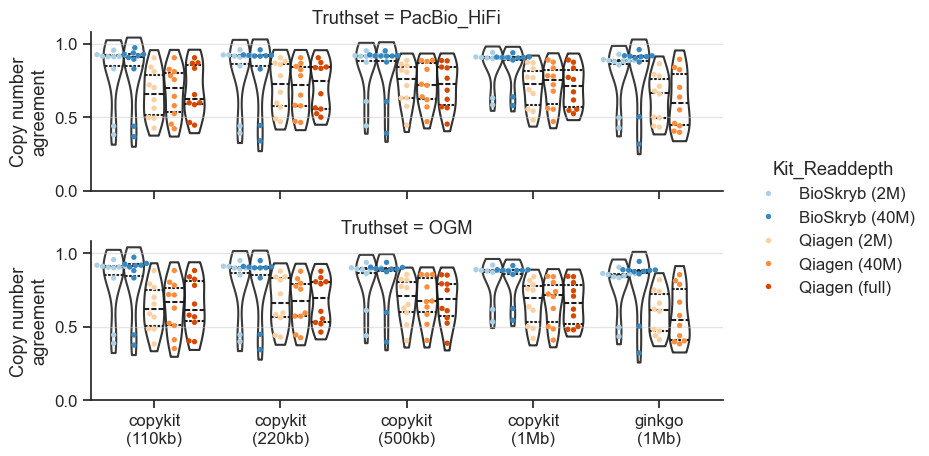

In [209]:
d = data.query("IsSingleCell == True & Benchtype == 'cn' & Binsize != 'none'")
plot_agreement(d, "Copy number\nagreement", figdir / "cnv_benchmark_singlecell_cn_agreement.svg")

### Gain/loss agreement

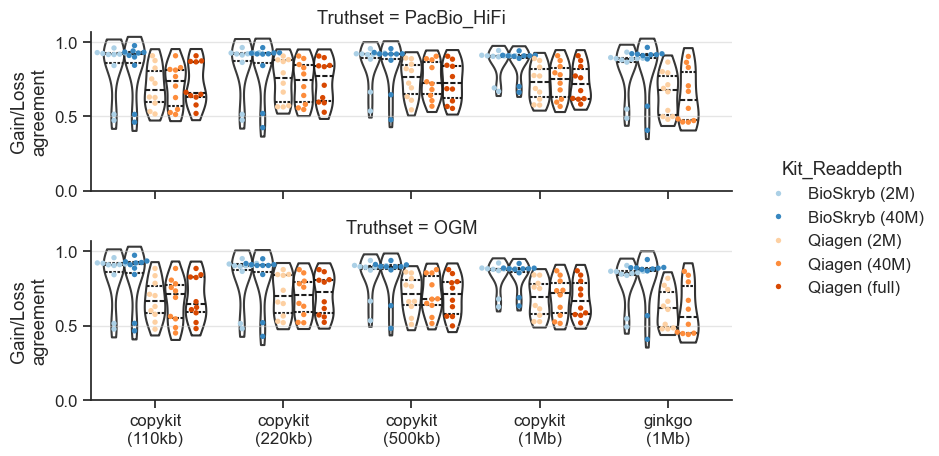

In [210]:
d = data.query("IsSingleCell == True & Benchtype == 'gl' & Binsize != 'none'")
plot_agreement(d, "Gain/Loss\nagreement", figdir / "cnv_benchmark_singlecell_gl_agreement.svg")

### Copy number agreement (w/o B cell 7&8)

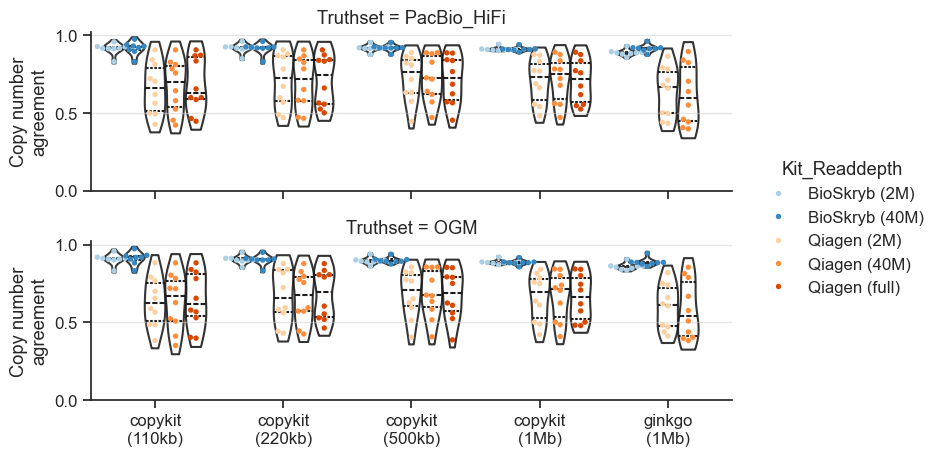

In [211]:
d = data.query("IsSingleCell == True & Benchtype == 'cn' & Binsize != 'none'")
skip_samples = [
    'B_C1_cell_07',
    'B_C2_cell_08',
]
d = d[~(d["User ID"].isin(skip_samples))]

plot_agreement(d, "Copy number\nagreement", figdir / "cnv_benchmark_singlecell_cn_agreement_filtered.svg")

In [212]:
d.isna().any()

NGI ID            False
Agreement         False
Truthset          False
Caller            False
Binsize           False
Readdepth         False
Benchtype         False
User ID           False
IsSingleCell      False
Kit               False
Sample            False
Genome            False
SampleName        False
Type              False
Caller_Binsize    False
Kit_Readdepth     False
dtype: bool

In [213]:
d

,NGI ID,Agreement,Truthset,Caller,Binsize,Readdepth,Benchtype,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Caller_Binsize,Kit_Readdepth
99,P33410_1001,0.835004,PacBio_HiFi,copykit,1Mb,full,cn,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,copykit\n(1Mb),Qiagen (full)
100,P33410_1002,0.771449,PacBio_HiFi,copykit,1Mb,full,cn,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell,copykit\n(1Mb),Qiagen (full)
101,P33410_1003,0.547103,PacBio_HiFi,copykit,1Mb,full,cn,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell,copykit\n(1Mb),Qiagen (full)
102,P33410_1004,0.889703,PacBio_HiFi,copykit,1Mb,full,cn,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell,copykit\n(1Mb),Qiagen (full)
103,P33410_1005,0.617754,PacBio_HiFi,copykit,1Mb,full,cn,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell,copykit\n(1Mb),Qiagen (full)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122,P33410_1016,0.840200,OGM,ginkgo,1Mb,2M,cn,B_B2_cell_04,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#04),Single cell,ginkgo\n(1Mb),BioSkryb (2M)
1123,P33410_1017,0.904981,OGM,ginkgo,1Mb,2M,cn,B_B3_cell_05,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#05),Single cell,ginkgo\n(1Mb),BioSkryb (2M)
1124,P33410_1018,0.834741,OGM,ginkgo,1Mb,2M,cn,B_B4_cell_06,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#06),Single cell,ginkgo\n(1Mb),BioSkryb (2M)
1127,P33410_1021,0.860774,OGM,ginkgo,1Mb,2M,cn,B_C3_cell_09,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#09),Single cell,ginkgo\n(1Mb),BioSkryb (2M)


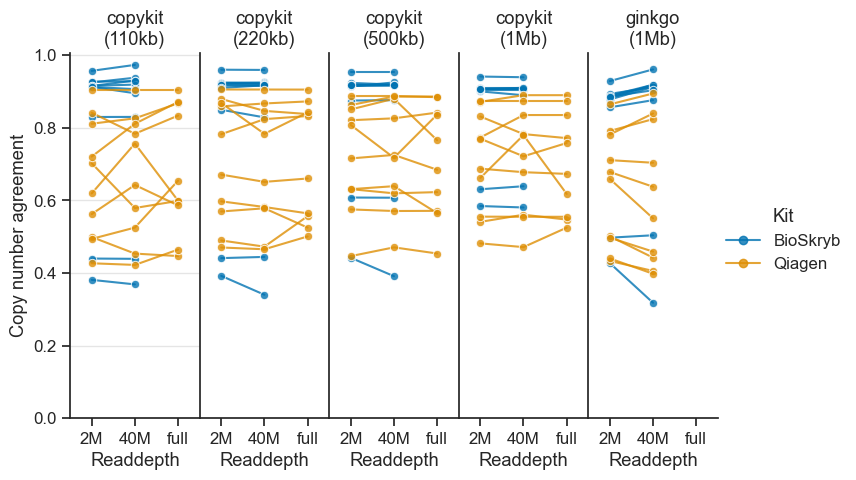

In [214]:
d = data.query("IsSingleCell == True & Benchtype == 'cn' & Binsize != 'none' & Truthset == 'PacBio_HiFi'")
d = d.sort_values(["Kit_Readdepth"])

hue_order = sorted(d["Kit_Readdepth"].unique())
d["Range"] = d["Kit_Readdepth"].map(dict(zip(hue_order, range(len(hue_order)))))
col_order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
g = sns.relplot(
    data=d, 
    kind="line",
    x="Readdepth",
    #order=hue_order,
    col_order=col_order, 
    y="Agreement", 
    hue="Kit",
    style="Kit",
    dashes=False,
    #hue_order=hue_order,
    #palette=palette,
    col="Caller_Binsize",
    palette="colorblind",
    units="SampleName",
    aspect=0.3,
    markers=["o", "o"],
    alpha=0.8,
    height=5,
    estimator=None)

g.set(ylabel="Copy number agreement")
g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    ax.set_ylim(bottom=0)
    ax.set_xlim(left=-0.5, right=2.5)
    ax.grid(True, axis='y', alpha=0.5)
    if not ax.get_subplotspec().is_first_col():
        ax.get_yaxis().set_visible(False)


g.figure.subplots_adjust(wspace=0)
        

plt.savefig(figdir / "cnv_benchmark_singlecell_cn_agreement_pacbio.svg", bbox_inches="tight", transparent=True)

In [215]:
d.groupby(["Kit", "Readdepth", "Caller", "Binsize"])["Agreement"].median().reset_index()\
 .pivot(index=["Readdepth", "Caller", "Binsize"], columns="Kit", values="Agreement").round(2).reset_index()

Kit,Readdepth,Caller,Binsize,BioSkryb,Qiagen
0,2M,copykit,110kb,0.91,0.66
1,2M,copykit,1Mb,0.91,0.73
2,2M,copykit,220kb,0.92,0.73
3,2M,copykit,500kb,0.92,0.76
4,2M,ginkgo,1Mb,0.88,0.67
5,40M,copykit,110kb,0.91,0.70
6,40M,copykit,1Mb,0.91,0.75
7,40M,copykit,220kb,0.92,0.72
8,40M,copykit,500kb,0.92,0.72
9,40M,ginkgo,1Mb,0.91,0.59


### Gain/loss agreement (w/o B cell 7&8)

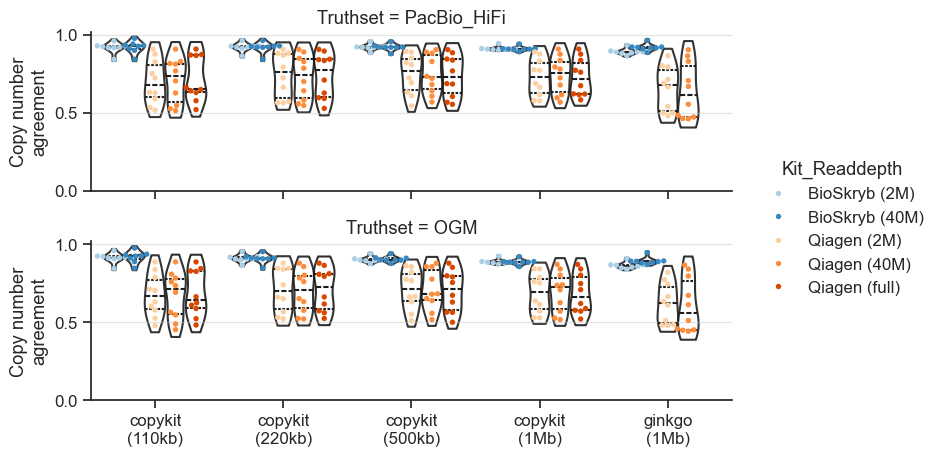

In [216]:
d = data.query("IsSingleCell == True & Benchtype == 'gl' & Binsize != 'none'")
skip_samples = [
    'B_C1_cell_07',
    'B_C2_cell_08',
]
d = d[~(d["User ID"].isin(skip_samples))]
plot_agreement(d, "Copy number\nagreement", figdir / "cnv_benchmark_singlecell_gl_agreement_filtered.svg")

### Bulk samples

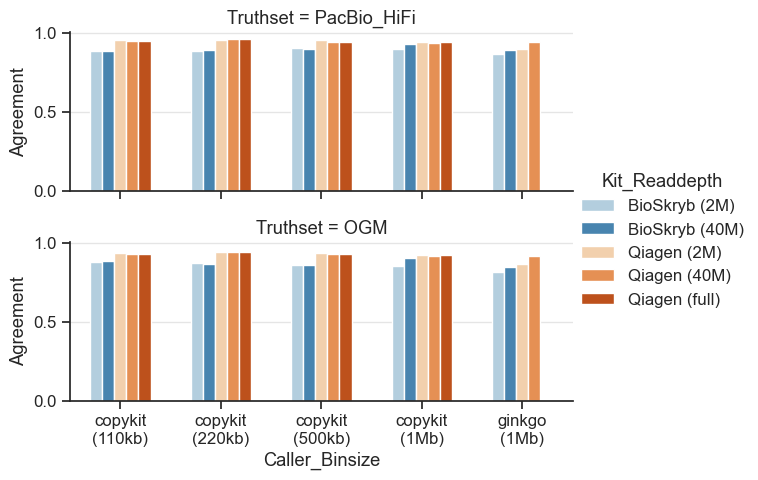

In [217]:
d = data.query("IsSingleCell == False & Benchtype == 'cn' & Binsize != 'none'")

hue_order = sorted(d["Kit_Readdepth"].unique())
order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
g = sns.catplot(
    data=d, 
    kind="bar",
    x="Caller_Binsize",
    order=order, 
    y="Agreement", 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette=palette,
    row="Truthset",
    aspect=2.5, 
    height=2.5,
    dodge=True,
    width=0.6,
)
#g.set(ylim=(0.8, 1))
# Add grid
for ax in g.axes.flat:
    ax.grid(True, axis='y', alpha=0.5)

In [218]:
data.query("Benchtype == 'cn' & Binsize != 'none'")\
    .groupby(["Kit", "IsSingleCell"]).agg(
    mean_agreement=("Agreement", "mean"),
    std_agreement=("Agreement", "std"),
).reset_index()

,Kit,IsSingleCell,mean_agreement,std_agreement
0,BioSkryb,False,0.878251,0.025236
1,BioSkryb,True,0.816306,0.179494
2,Qiagen,False,0.933994,0.020023
3,Qiagen,True,0.671363,0.156530


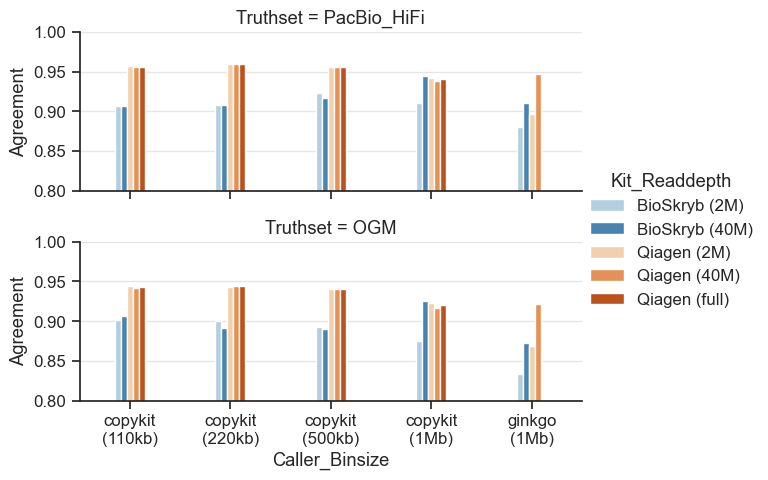

In [219]:
d = data.query("IsSingleCell == False & Benchtype == 'gl' & Binsize != 'none'")

hue_order = sorted(d["Kit_Readdepth"].unique())
order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
g = sns.catplot(
    data=d, 
    kind="bar",
    x="Caller_Binsize",
    order=order, 
    y="Agreement", 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette=palette,
    row="Truthset",
    aspect=2.5, 
    height=2.5,
    dodge=True,
    width=0.3,
)
g.set(ylim=(0.8, 1))
# Add grid
for ax in g.axes.flat:
    ax.grid(True, axis='y', alpha=0.5)

### Read depth improvement

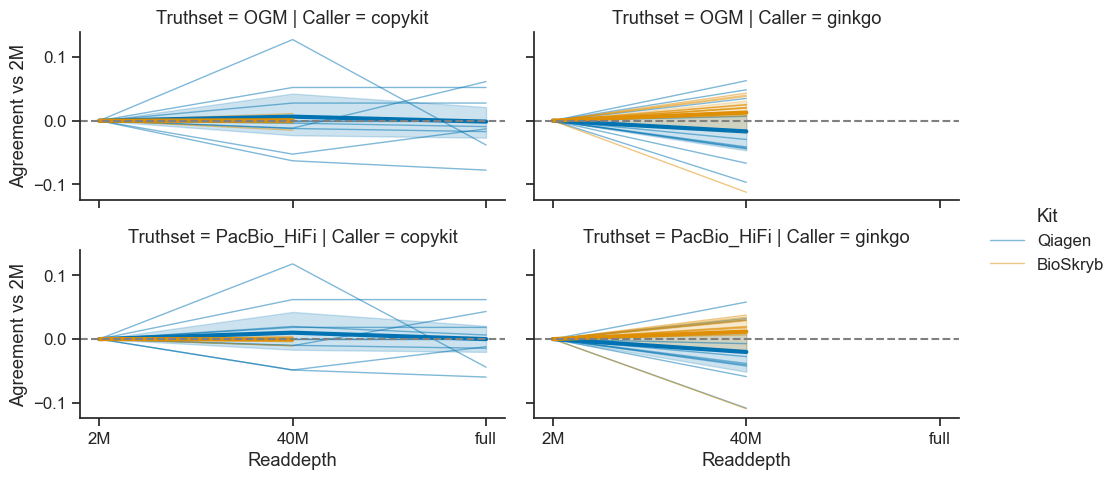

In [220]:
d = data.query("Benchtype == 'cn' & Binsize == '1Mb' & IsSingleCell == True & Binsize != 'none'")
d = d.sort_values("Readdepth")
d["Agreement vs 2M"] = d.groupby(["NGI ID", "Caller", "Truthset"])["Agreement"].transform(lambda x: x - x.iloc[0])
g = sns.relplot(
    data=d, 
    kind="line",
    x="Readdepth",
    #size="Binsize",
    #size_order=reversed(["110kb", "220kb", "500kb", "1Mb"]),
    #order=order, 
    col="Caller",
    #style_order=[True, False],
    hue_order=["Qiagen", "BioSkryb"],
    y="Agreement vs 2M",
    hue="Kit",
    row="Truthset",
    aspect=2, 
    height=2.5,
    lw=1,
    estimator=None,
    alpha=0.5,
    units="NGI ID",
    #dodge=True,
    #width=0.3,
)
g.map_dataframe(
    sns.lineplot,
    x="Readdepth",
    y="Agreement vs 2M",
    hue="Kit",
    data=d, 
    hue_order=["Qiagen", "BioSkryb"],
    lw=3,
)
g.refline(y=0)
#g.set(ylim=(0, 1))

### SNP array

In [221]:
data["Caller"].unique()

array(['penncnv', 'copykit', 'ginkgo'], dtype=object)

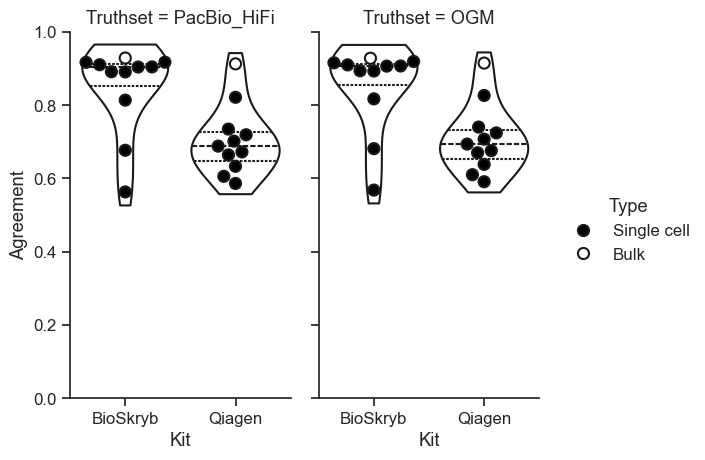

In [222]:
d = data.query("Benchtype == 'cn' & Caller == 'penncnv'").copy()
g = sns.catplot(
    data=d,
    kind="swarm",
    x="Kit",
    y="Agreement",
    hue="Type",
    hue_order=["Single cell", "Bulk"],
    col="Truthset",
    edgecolor="k",
    linewidth=1.5,
    palette=["black", "white"],
    height=4.8,
    aspect=0.6,
    width=0.3,
    size=8
)
g.map_dataframe(
    sns.violinplot,
    data=d.query("IsSingleCell == True"),
    x="Kit",
    y="Agreement",
    fill=None,
    color="k",
    inner="quart",
    cut=0.5,
    )
g.set(ylim=(0, 1))

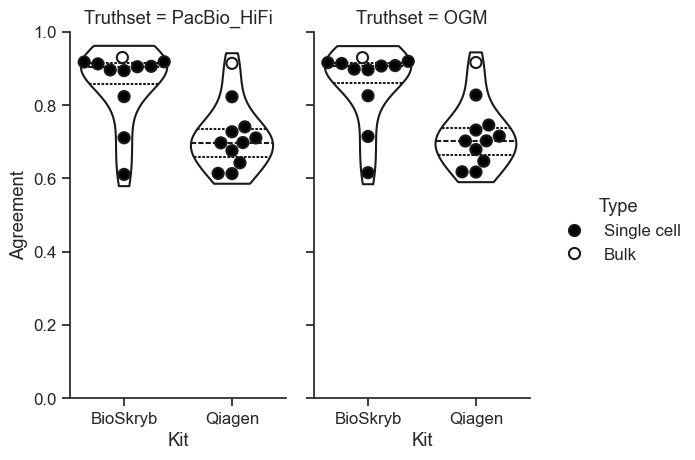

In [223]:
d = data.query("Benchtype == 'gl' & Caller == 'penncnv'").copy()
g = sns.catplot(
    data=d,
    kind="swarm",
    x="Kit",
    y="Agreement",
    hue="Type",
    hue_order=["Single cell", "Bulk"],
    col="Truthset",
    edgecolor="k",
    linewidth=1.5,
    palette=["black", "white"],
    height=4.8,
    aspect=0.6,
    width=0.3,
    size=8
)
g.map_dataframe(
    sns.violinplot,
    data=d.query("IsSingleCell == True"),
    x="Kit",
    y="Agreement",
    fill=None,
    color="k",
    inner="quart",
    cut=0.5,
    )
g.set(ylim=(0, 1))

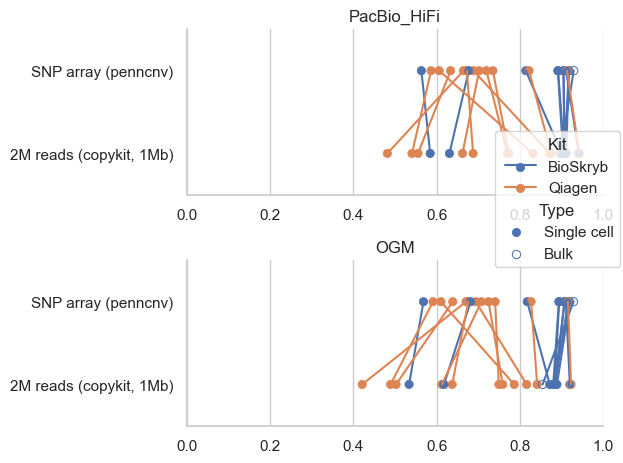

In [224]:
readdepth = ["2M", "array"]
caller = ["penncnv", "copykit"]
binsize = ["none", "1Mb"]
d = data.query("Benchtype == 'cn' & Readdepth in @readdepth & Caller in @caller & Binsize in @binsize").copy()
d["Caller_Binsize"] = d["Caller"] + "\n(" + d["Binsize"] + ")"

d["data"] = d["Readdepth"].replace({
    "2M": "2M reads (copykit, 1Mb)",
    "array": "SNP array (penncnv)"
})
d = d.sort_values("Type", ascending=False)
p = (
    so.Plot(d, y="data", x="Agreement", color="Kit", group="SampleName")
    .facet(row="Truthset")
    .share(x=False)
    .add(so.Dot(), fill="Type")
    .add(so.Path())#, so.Dodge(by=["color"]), )
    .label(y="", x="")
    .limit(x=(0, 1))
    .scale(
        color=so.Nominal(order=["BioSkryb", "Qiagen"]),
        y=so.Nominal(order=["SNP array (penncnv)", "2M reads (copykit, 1Mb)"]),
    )
    .layout(engine="tight")
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .save(figdir / "cnv_benchmark_array_vs_2M.svg", dpi=300, bbox_inches="tight", transparent=True)
)
p.show()


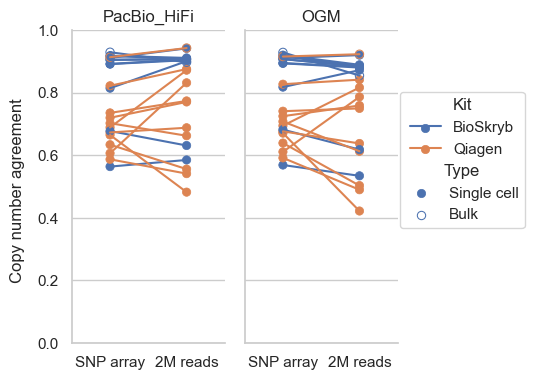

In [225]:
readdepth = ["2M", "array"]
caller = ["penncnv", "copykit"]
binsize = ["none", "1Mb"]
d = data.query("Benchtype == 'cn' & Readdepth in @readdepth & Caller in @caller & Binsize in @binsize").copy()
d["Caller_Binsize"] = d["Caller"] + "\n(" + d["Binsize"] + ")"

d["data"] = d["Readdepth"].replace({
    "2M": "2M reads",
    "array": "SNP array"
})
d = d.sort_values("Type", ascending=False)
fig = plt.figure(figsize=(4,4))
fig.text(0, 0.5, "Copy number agreement", ha="center", va="center", rotation=90, fontsize=12)
p = (
    so.Plot(d, x="data", y="Agreement", color="Kit", group="SampleName")
    .facet(col="Truthset")
    .add(so.Dot(), fill="Type")
    .add(so.Path())#, so.Dodge(by=["color"]), )
    .label(y="", x="")
    .limit(y=(0, 1))
    .scale(
        color=so.Nominal(order=["BioSkryb", "Qiagen"]),
        x=so.Nominal(order=["SNP array", "2M reads"]),
    )
    .layout(engine="tight")
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .on(fig)
    .save(figdir / "cnv_benchmark_array_vs_2M.svg", dpi=300, bbox_inches="tight", transparent=True)
)


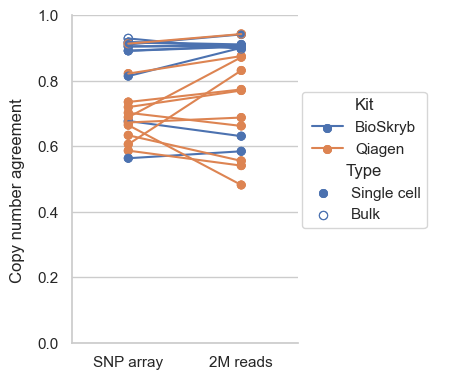

In [226]:
readdepth = ["2M", "array"]
caller = ["penncnv", "copykit"]
binsize = ["none", "1Mb"]
d = data.query(
    "Benchtype == 'cn' & Readdepth in @readdepth & Caller in @caller\
    & Binsize in @binsize & Truthset == 'PacBio_HiFi'").copy()
d["Caller_Binsize"] = d["Caller"] + "\n(" + d["Binsize"] + ")"

d["data"] = d["Readdepth"].replace({
    "2M": "2M reads",
    "array": "SNP array"
})
d = d.sort_values("Type", ascending=False)
fig = plt.figure(figsize=(3,4))
fig.text(0, 0.5, "Copy number agreement", ha="center", va="center", rotation=90, fontsize=12)
p = (
    so.Plot(d, x="data", y="Agreement", color="Kit", group="SampleName")
    .add(so.Dot(), fill="Type")
    .add(so.Dot(), fill="Type")
    .add(so.Path())#, so.Dodge(by=["color"]), )
    .label(y="", x="")
    .limit(y=(0, 1))
    .scale(
        color=so.Nominal(order=["BioSkryb", "Qiagen"]),
        x=so.Nominal(order=["SNP array", "2M reads"]),
    )
    .layout(engine="tight")
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .on(fig)
    .save(figdir / "cnv_benchmark_array_vs_2M_pacbio.svg", dpi=300, bbox_inches="tight", transparent=True)
)


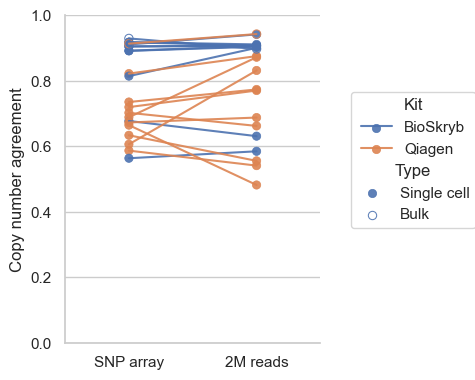

In [266]:
readdepth = ["2M", "array"]
caller = ["penncnv", "copykit"]
binsize = ["none", "1Mb"]
d = data.query(
    "Benchtype == 'cn' & Readdepth in @readdepth & Caller in @caller\
    & Binsize in @binsize & Truthset == 'PacBio_HiFi'").copy()
d["Caller_Binsize"] = d["Caller"] + "\n(" + d["Binsize"] + ")"

d["data"] = d["Readdepth"].replace({
    "2M": "2M reads",
    "array": "SNP array"
})
d = d.sort_values("Type", ascending=False)
fig = plt.figure(figsize=(3.5,4))
p = (
    so.Plot(d, x="data", y="Agreement", color="Kit", group="SampleName")
    .add(so.Dot(alpha=0.9), fill="Type")
    .add(so.Path(alpha=0.9))#, so.Dodge(by=["color"]), )

    # .add(so.Range(linewidth=2, alpha=1), so.Est(errorbar=("pi", 50)), so.Dodge(), 
    #      group=None, data=d.query("Type == 'Single cell'"), legend=False)
    # .add(so.Dot(marker="_", stroke=3, pointsize=10), so.Agg("median"), so.Dodge(), 
    #      group=None, data=d.query("Type == 'Single cell'"), legend=False)

    
    .label(y="Copy number agreement", x="")
    .limit(y=(0, 1))
    .scale(
        color=so.Nominal(order=["BioSkryb", "Qiagen"]),
        x=so.Nominal(order=["SNP array", "2M reads"]),
    )
    .layout(engine="tight")
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .on(fig)
    .save(figdir / "cnv_benchmark_array_vs_2M_pacbio.svg", dpi=300, bbox_inches="tight", transparent=True)
)


In [ ]:
data.query("IsSingleCell == True & Benchtype == 'cn'")
hue_order = sorted(d["Kit_Readdepth"].unique())
order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
g = sns.catplot(
    data=d, 
    kind="swarm",
    x="Caller_Binsize",
    order=order, 
    y="Agreement", 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette=palette,
    row="Truthset",
    aspect=3, 
    s=15,
    height=2.5,
    dodge=True,
    width=0.3,
)

g.map_dataframe(
    sns.violinplot,
    data=d, 
    x="Caller_Binsize",
    y="Agreement",
    inner="quart", 
    fill=None, 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette="dark:k", 
    dodge=True,
    density_norm="width",
    zorder=-1,
    alpha=0.9,
    cut=0.5,
)

g.set(ylabel=ylabel, xlabel="")

for ax in g.axes.flat:
    ax.set_ylim(bottom=0)
    ax.grid(True, axis='y', alpha=0.5)



## Agreement truthsets

In [249]:
truth = []
t1 = pd.read_csv(base_path / "agreement_truthsets.cn.tsv", sep="\t", names=["Query", "Agreement"])
t1["Benchtype"] = "Copy number"
t2 = pd.read_csv(base_path / "agreement_truthsets.gl.tsv", sep="\t", names=["Query", "Agreement"])
t2["Benchtype"] = "Gain/Loss"
truth = pd.concat([t1, t2])
truth


,Query,Agreement,Benchtype
0,OGM,0.987892,Copy number
0,OGM,0.990732,Gain/Loss


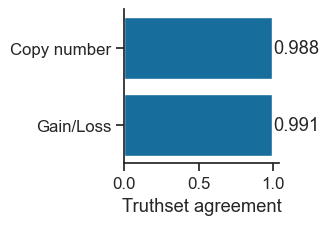

In [255]:
fig, ax = plt.subplots(figsize=(2, 2))
ax = sns.barplot(data=truth, y="Benchtype", x="Agreement")
ax.set_xlabel("Truthset agreement")
ax.set_ylabel("")

# Add values after bars
for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", (p.get_width() * 1.01, p.get_y() + p.get_height() / 2), ha="left", va="center")

## Truthsets comparison

In [408]:
def parse_fai(fai):
    with open(fai) as f:
        for line in f:
            chrom, length, *_ = line.strip().split("\t")
            yield chrom, int(length)


def parse_seg(seg):
    with open(seg) as f:
        for line in f:
            if line.startswith("#"):
                continue
            
            # The third column should be an integer
            if not line.strip().split("\t")[2].isdigit():
                continue

            els = line.strip().split("\t")
            name = els[0]
            chrom = els[1]
            start = int(els[2])
            end = int(els[3])
            cn = int(els[-1])

            yield name, chrom, start, end, cn

ogm_seg = "../resources/OGM_CNVs/cnv_calls.chr.seg"
pb_seg = "../resources/PacBioHiFi_pr_023_003_MM1S_hificnv/MM1S_excluded.pr_023_003.seg"
fai = "../resources/GRCh38.genome"

chr_lengths = {chrom: length for chrom, length in parse_fai(fai)}

ogm_cnvs = list(parse_seg(ogm_seg))
pb_cnvs = list(parse_seg(pb_seg))

cnvs = pd.DataFrame(ogm_cnvs + pb_cnvs, columns=["Name", "Chrom", "Start", "End", "CN"])
cnvs = cnvs[cnvs["Chrom"].isin(chr1toX)]
#cnvs = cnvs.query("CN != 2")
chromsome_offsets = {}
position = 0
spacing = 20_000_000
for chrom in chr1toX:
    chromsome_offsets[chrom] = position
    position += chr_lengths[chrom] + spacing

cnvs["Position"] = cnvs.apply(lambda x: chromsome_offsets[x["Chrom"]] + x["Start"], axis=1)

cnvs

,Name,Chrom,Start,End,CN,Position
0,OGM,chr1,82856335,85109746,1,82856335
1,OGM,chr1,92697635,100769576,1,92697635
2,OGM,chr1,100783411,107392774,1,100783411
3,OGM,chr1,107403070,120615069,1,107403070
4,OGM,chr1,120924651,121608073,1,120924651
...,...,...,...,...,...,...
261,PacBio_HiFi_HiFiCNV,chrX,62518000,141000000,2,3377519522
262,PacBio_HiFi_HiFiCNV,chrX,141000000,141014000,5,3456001522
263,PacBio_HiFi_HiFiCNV,chrX,141014000,141534000,2,3456015522
264,PacBio_HiFi_HiFiCNV,chrX,141534000,141562000,0,3456535522


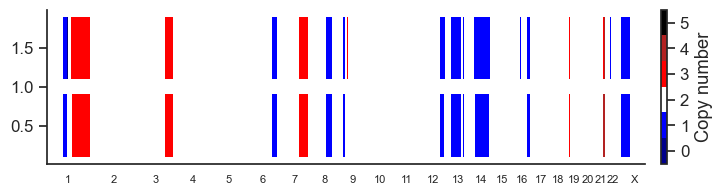

In [416]:
import matplotlib as mpl

cn_colors = {
    0: "darkblue",
    1: "blue",
    2: "white",
    3: "red",
    4: "firebrick",
    5: "darkred",
    6: "black",
}

cmap = mpl.colors.ListedColormap(list(cn_colors.values()))
bounds = list(cn_colors.keys())
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

fig, (ax, cax) = plt.subplots(figsize=(8, 2), ncols=2, 
                       gridspec_kw={"width_ratios": [1,0.01]})

for i, (group, cnv) in enumerate(cnvs.groupby("Name")):
    x = cnv["Position"].values
    bar_widths= (cnv["End"] - cnv["Start"]).values
    y = i + 0.1
    facecolors = norm(cnv["CN"].values)
    facecolors = [cmap(f) for f in facecolors]
    xranges = np.array([x, bar_widths]).T
    ax.broken_barh(
        xranges=xranges,
        yrange=(y, 0.8),
        facecolors=facecolors,
        cmap=cmap,
        linewidth=0,
    )

#  Add a colorbar
cb = mpl.colorbar.ColorbarBase(
    cax,
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    cmap=cmap,
    spacing='proportional', 
    orientation='vertical', label="Copy number"
)
cb.ax.set_yticklabels(["0", "1", "2", "3", "4", "5"])
# Remove minor ticks on colorbar
cb.ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.set_xlim(0, cnvs["Position"].max())
ax.xaxis.set_visible(False)
fig.subplots_adjust(wspace=0.05)

# Add chromosome labels and regions to the plot
for i, chrom in enumerate(chr1toX):
    length = chr_lengths[chrom]
    ax.text(chromsome_offsets[chrom] + length / 2, -0.2, chrom.replace("chr", ""), ha="center", va="center", fontsize=8)

    # if i % 2 == 1:
    #     ax.axvspan(chromsome_offsets[chrom], chromsome_offsets[chrom] + length, color="lightgrey", alpha=0.4, zorder=-1)
    # # else:
    #     ax.axvspan(chromsome_offsets[chrom], chromsome_offsets[chrom] + length, color="lightgrey", alpha=0.8, zorder=-1)

    

## Truvari data

In [151]:
df = pd.read_csv("../analysis/cnv_benchmark/truvari.tsv", sep="\t")
df["NGI ID"] = df["sample"]
df = df.merge(samples, on="NGI ID")
df["Caller_Binsize"] = df[["caller","binsize"]].apply(lambda x: f"{x[0]}\n({x[1]})", axis=1)
df["Kit_Readdepth"] = df[["Kit","reads"]].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)
df

/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/4066613567.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df["Caller_Binsize"] = df[["caller","binsize"]].apply(lambda x: f"{x[0]}\n({x[1]})", axis=1)
/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/4066613567.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df["Kit_Readdepth"] = df[["Kit","reads"]].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)


,caller,reads,binsize,sample,TP-base,TP-comp,FP,FN,precision,recall,...,gt_concordance,gt_matrix,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,Caller_Binsize,Kit_Readdepth
0,copykit,2M,110kb,P33410_1001,7,7,14,72,0.333333,0.088608,...,1.0,"{'(0, 1)': {'(0, 1)': 7}}",P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,copykit\n(110kb),Qiagen (2M)
1,copykit,2M,110kb,P33410_1002,6,6,26,73,0.187500,0.075949,...,1.0,"{'(0, 1)': {'(0, 1)': 6}}",P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,copykit\n(110kb),Qiagen (2M)
2,copykit,2M,110kb,P33410_1003,7,7,26,72,0.212121,0.088608,...,1.0,"{'(0, 1)': {'(0, 1)': 7}}",P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,copykit\n(110kb),Qiagen (2M)
3,copykit,2M,110kb,P33410_1004,7,7,13,72,0.350000,0.088608,...,1.0,"{'(0, 1)': {'(0, 1)': 7}}",P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,copykit\n(110kb),Qiagen (2M)
4,copykit,2M,110kb,P33410_1005,5,5,24,74,0.172414,0.063291,...,1.0,"{'(0, 1)': {'(0, 1)': 5}}",P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,copykit\n(110kb),Qiagen (2M)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,ginkgo,40M,1Mb,P33410_1019,7,7,82,25,0.078652,0.218750,...,1.0,"{'(0, 1)': {'(0, 1)': 7}}",P33410_1019,B_C1_cell_07,True,BioSkryb,MM1S cell line,Human,ginkgo\n(1Mb),BioSkryb (40M)
216,ginkgo,40M,1Mb,P33410_1020,5,5,48,27,0.094340,0.156250,...,1.0,"{'(0, 1)': {'(0, 1)': 5}}",P33410_1020,B_C2_cell_08,True,BioSkryb,MM1S cell line,Human,ginkgo\n(1Mb),BioSkryb (40M)
217,ginkgo,40M,1Mb,P33410_1021,7,7,11,25,0.388889,0.218750,...,1.0,"{'(0, 1)': {'(0, 1)': 7}}",P33410_1021,B_C3_cell_09,True,BioSkryb,MM1S cell line,Human,ginkgo\n(1Mb),BioSkryb (40M)
218,ginkgo,40M,1Mb,P33410_1022,7,7,12,25,0.368421,0.218750,...,1.0,"{'(0, 1)': {'(0, 1)': 7}}",P33410_1022,B_C4_cell_10,True,BioSkryb,MM1S cell line,Human,ginkgo\n(1Mb),BioSkryb (40M)


/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/2147112444.py:14: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.swarmplot(
/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/2147112444.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax = sns.violinplot(


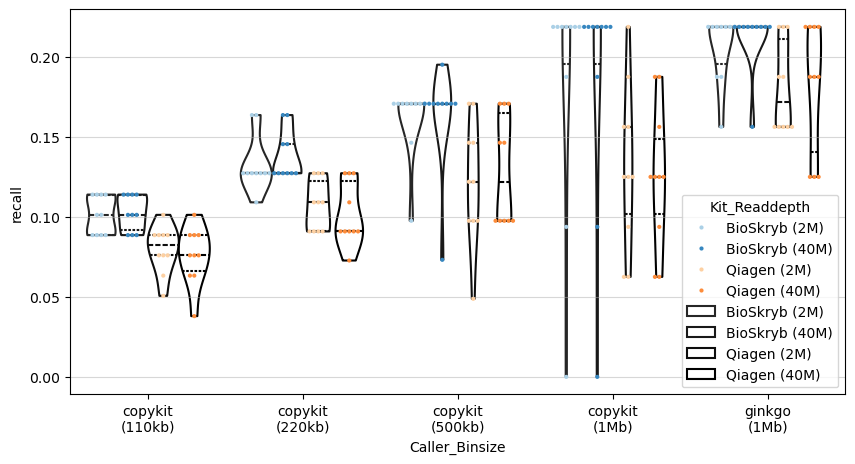

In [155]:
d = df.query("IsSingleCell == True")

hue_order = sorted(d["Kit_Readdepth"].unique())
order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
score = "recall"
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.swarmplot(
    data=d, 
    x="Caller_Binsize",
    order=order, 
    y=score, 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette=palette,
    s=3,
    dodge=True,
    ax=ax
)
ax = sns.violinplot(
    data=d, 
    x="Caller_Binsize",
    y=score,
    inner="quart", 
    fill=None, 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    color="k", 
    dodge=True,
    zorder=-1,
    cut=0,
)
ax.grid(True, axis='y', alpha=0.5)

/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/2964249.py:14: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.swarmplot(
/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/2964249.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax = sns.violinplot(


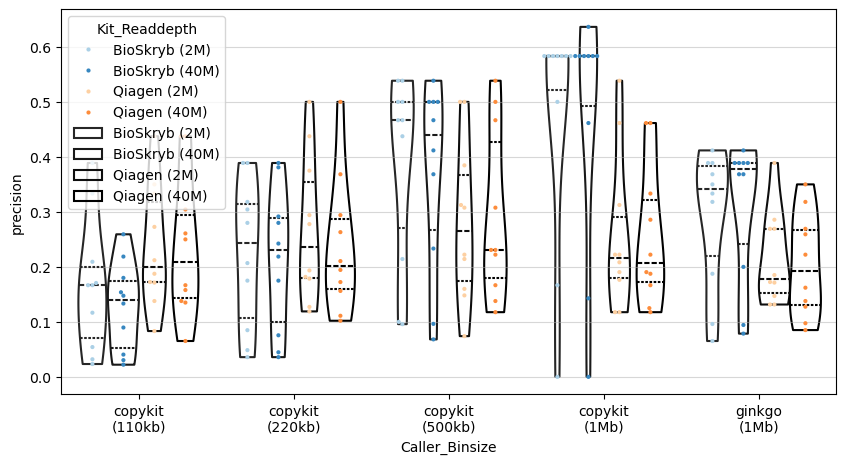

In [156]:
d = df.query("IsSingleCell == True")

hue_order = sorted(d["Kit_Readdepth"].unique())
order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
score = "precision"
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.swarmplot(
    data=d, 
    x="Caller_Binsize",
    order=order, 
    y=score, 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette=palette,
    s=3,
    dodge=True,
    ax=ax
)
ax = sns.violinplot(
    data=d, 
    x="Caller_Binsize",
    y=score,
    inner="quart", 
    fill=None, 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    color="k", 
    dodge=True,
    zorder=-1,
    cut=0,
)
ax.grid(True, axis='y', alpha=0.5)

/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/776355916.py:14: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.swarmplot(
/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/776355916.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax = sns.violinplot(


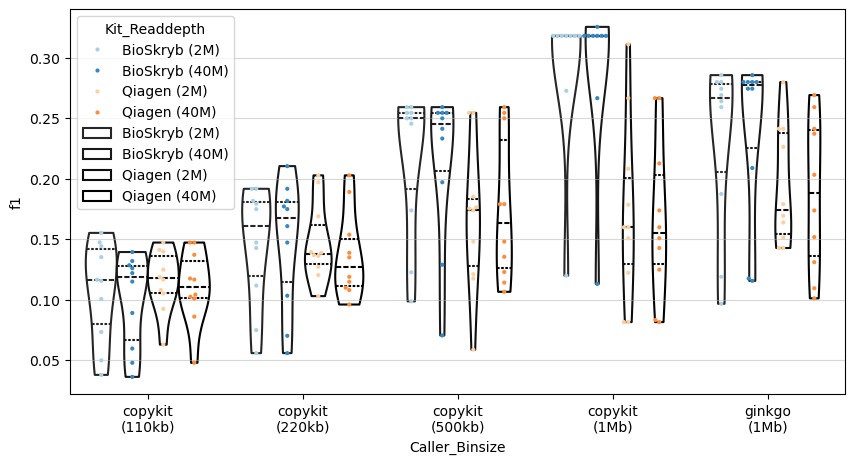

In [157]:
d = df.query("IsSingleCell == True")

hue_order = sorted(d["Kit_Readdepth"].unique())
order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
score = "f1"
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.swarmplot(
    data=d, 
    x="Caller_Binsize",
    order=order, 
    y=score, 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette=palette,
    s=3,
    dodge=True,
    ax=ax
)
ax = sns.violinplot(
    data=d, 
    x="Caller_Binsize",
    y=score,
    inner="quart", 
    fill=None, 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    color="k", 
    dodge=True,
    zorder=-1,
    cut=0,
)
ax.grid(True, axis='y', alpha=0.5)

/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/2728239462.py:19: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  g = sns.relplot(


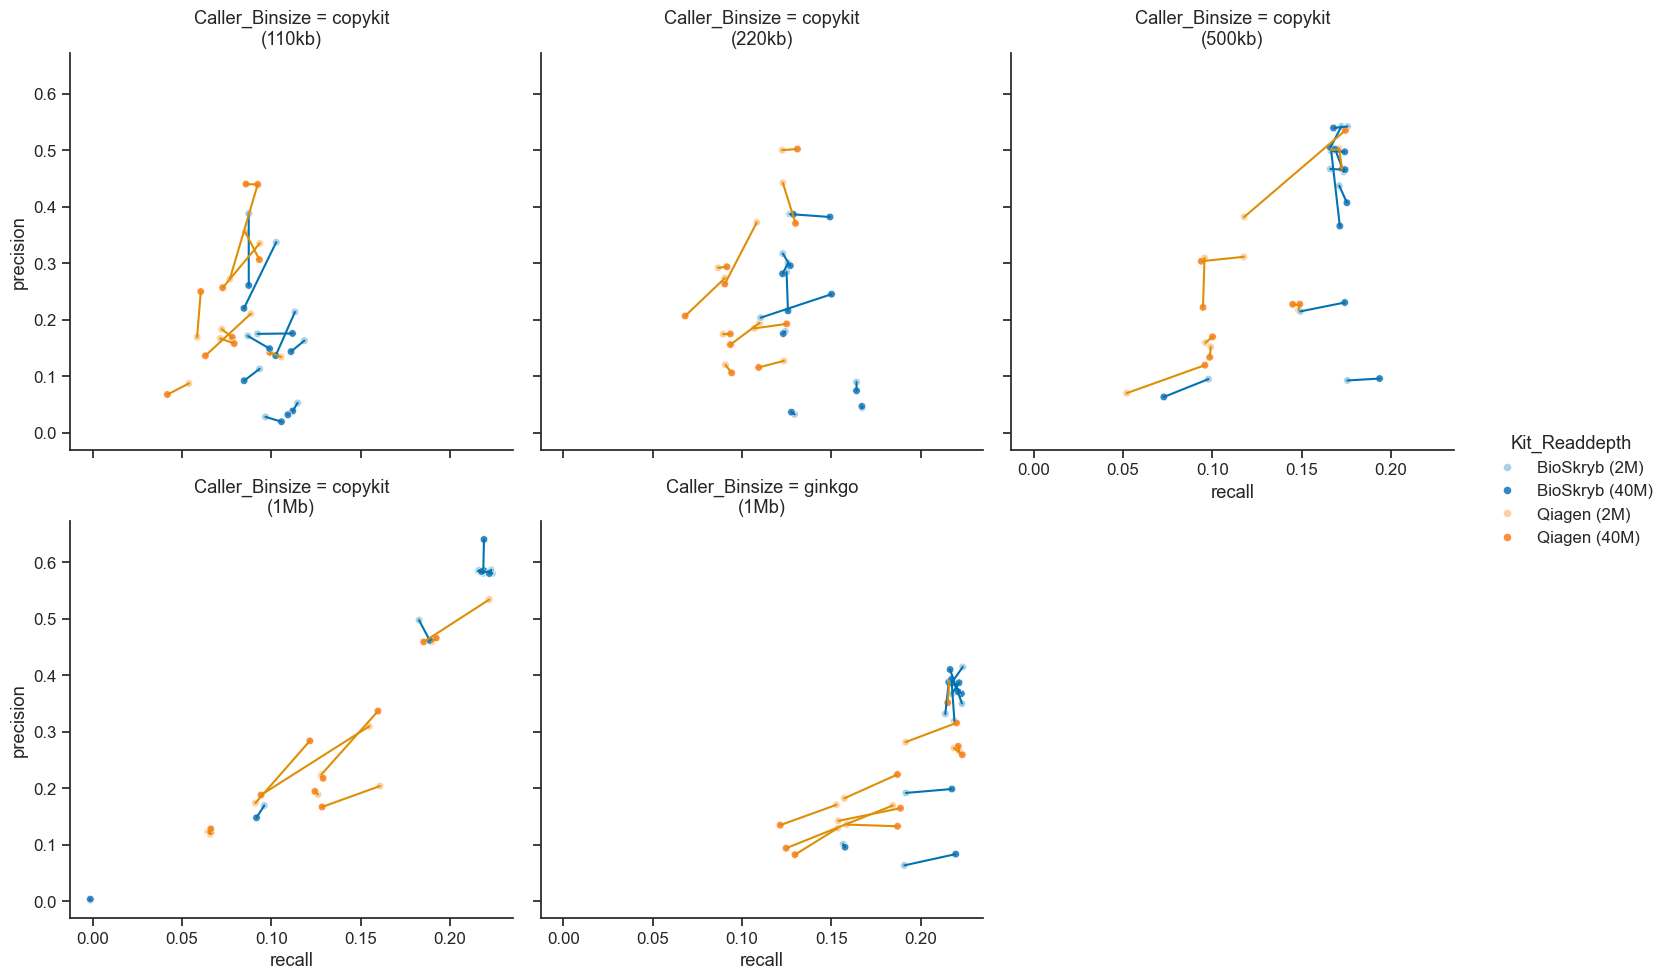

In [223]:
import random
def jitter(x, jitter):
    return x + random.uniform(-jitter, jitter)

d = df.query("IsSingleCell == True").copy()
d["recall"] = d["recall"].apply(lambda x: jitter(x, 0.005))
d["precision"] = d["precision"].apply(lambda x: jitter(x, 0.005))

hue_order = sorted(d["Kit_Readdepth"].unique())
order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
score = "f1"
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
g = sns.relplot(
    kind="scatter",
    data=d, 
    x="recall",
    y="precision",
    col="Caller_Binsize",
    col_wrap=3,
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette=palette,
    s=30,
)
g.map_dataframe(
    sns.lineplot,
    data=d,
    x="recall",
    y="precision",
    hue="Kit",
    hue_order=["BioSkryb", "Qiagen"],
    units="NGI ID",
    estimator=None,
)
